In [5]:
import numpy as np
import matplotlib.pyplot as plt
import miepython
import urllib.request as u
al_data,_ = u.urlretrieve("https://refractiveindex.info/data_csv.php?datafile=database/data-nk/main/Al/Rakic.yml", "Al_data.csv")
na_data,_ = u.urlretrieve("https://refractiveindex.info/data_csv.php?datafile=database/data-nk/main/Na/Smith.yml", "Na_data.csv")


In [6]:
with open(na_data) as AlData:
    AlData.readline()
    n = []
    k = []
    wavelength = []
    flag = 0
    for line in AlData:
        StrLine = line.rstrip()
        if flag == 0:
            if StrLine == "":
                flag = 1
                continue
            n.append(StrLine.split(",")[1])
            wavelength.append(StrLine.split(",")[0])
        elif flag == 1:
            flag = 2
            continue
        elif flag == 2:
            k.append(StrLine.split(",")[1])

realn = []
realk = []
realwl = []

realn = [float(i) for i in n]
print(realn)
realk = [float(i) for i in k]
realwl = [float(i) for i in wavelength]
cmplxRefractionIndex = []
for elem in list(zip(realn, realk)):
    cmplxRefractionIndex.append(complex(*elem))

[0.049195, 0.05522, 0.061078, 0.06512, 0.06896, 0.067744, 0.068302, 0.066149, 0.062846, 0.058647, 0.052637, 0.048526, 0.049548, 0.053026, 0.064101, 0.077963, 0.098586, 0.122821, 0.147176, 0.175119, 0.206644, 0.240865, 0.262406]


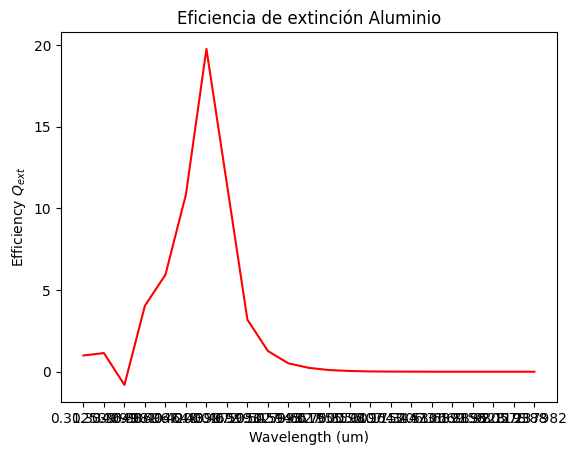

In [9]:
d = 90E-3
kont = 0
qext = []
while kont < len(realwl):
    qext.append( miepython.ez_mie(cmplxRefractionIndex[kont], d, realwl[kont])[0])
    kont += 1

min = 0
max = len(qext)-0
plt.plot(wavelength[min:max],qext[min:max],color='blue')
plt.xlabel("Wavelength (um)")
plt.ylabel("Efficiency $Q_{ext}$")
plt.title("Eficiencia de extinción Aluminio")
#plt.xlim(300,800)
#plt.ylim(1,2.5)
plt.show()